# Loss investigation — does `workers=1` fix the entangled synthetic loss curves?

**Question.** In `scripts/run_synthetic_benchmark.py` the per-epoch SGNS finetune
losses for the different variants sit almost on top of each other and look noisy,
unlike the DBpedia runs (`scripts/_invest_full_three.py`) where the curves
separate cleanly.

**Hypothesis under test.** The synthetic benchmark trains with `workers=16`, and
gensim's `compute_loss` accumulator is known to be unreliable under asynchronous
(Hogwild) multi-thread updates — especially on a small corpus. This notebook
re-runs **vanilla**, **p1**, **p2** on **tc07** with **`workers=1`**, using the
*exact* loss bookkeeping the benchmark uses (`get_latest_training_loss()`
per-epoch delta), to see whether single-threaded training de-noises /
de-entangles the curves.

We use the **classic** flavour of p1/p2 (protograph init, finetune LR = 0.025 —
the *same* LR as vanilla) so all three curves are compared at identical learning
rate, isolating the effect of the **initialization** rather than the LR. Flip
`BOUND = True` in the config cell to compare the protected-LR `*_bound` variants
instead.

In [1]:
import sys, time
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from gensim.models.callbacks import CallbackAny2Vec
from gensim.models.word2vec import LineSentence


def find_root(start: Path) -> Path:
    for cand in [start.resolve(), *start.resolve().parents]:
        if (cand / "scripts" / "_synthetic_compare.py").is_file():
            return cand
    raise RuntimeError("repo root (scripts/_synthetic_compare.py) not found")


ROOT = find_root(Path.cwd())
SCRIPTS = ROOT / "scripts"
if str(SCRIPTS) not in sys.path:
    sys.path.insert(0, str(SCRIPTS))

from _synthetic_compare import (
    concept_bound_vectors,
    ensure_walks,
    make_eval_fn,
    new_skipgram_model,
    normalized_stage1_vectors,
    pretrain_protograph,
    protograph_init,
    write_protographs,
)

# ---- config (mirrors scripts/run_synthetic_benchmark.py CFG) ----
WORKERS     = 1        # <-- the experiment: single-threaded
TC          = "tc07"
DIM         = 200
EPOCHS      = 5
PRETRAIN_EP = 5
WALKS_PER_E = 100      # instance walks: walks_instance_w100_d3.txt
PROTO_WALKS = 200
DEPTH       = 3
TARGET_NORM = 8.0
MIN_ALPHA   = 0.0001
SEED        = 42

BOUND       = False    # False -> *_classic (LR 0.025); True -> *_bound (LR 0.0025)
CLASSIC_LR  = 0.025
BOUND_LR    = 0.0025
VANILLA_LR  = 0.025
FT_LR       = BOUND_LR if BOUND else CLASSIC_LR
SUFFIX      = "bound" if BOUND else "classic"

print("ROOT =", ROOT)
print(f"workers={WORKERS}  tc={TC}  flavour={SUFFIX}")
print(f"finetune LR -> vanilla={VANILLA_LR}  p1/p2={FT_LR}")

ROOT = /home/bnukhkadiev/Knowledge-Graphs
workers=1  tc=tc07  flavour=classic
finetune LR -> vanilla=0.025  p1/p2=0.025


In [2]:
# --- paths; protographs + walks are cached on disk (calls below are no-ops if present) ---
tc_dir    = ROOT / "v1" / "synthetic_ontology" / TC / "synthetic_ontology"
ontology  = tc_dir / "ontology.nt"
graph     = tc_dir / "graph.nt"
train_txt = tc_dir / "1000" / "train_test" / "train.txt"
test_txt  = tc_dir / "1000" / "train_test" / "test.txt"
walk_dir  = ROOT / "notebooks" / "synthetic_compare" / TC
walk_dir.mkdir(parents=True, exist_ok=True)

proto_paths = write_protographs(ontology, walk_dir)
proto_walks = {
    k: ensure_walks(
        proto_paths[k], walk_dir / f"walks_{k}.txt",
        walks_per_entity=PROTO_WALKS, depth=DEPTH, seed=SEED,
        ensure_triple_coverage=True,
    )
    for k in ("p1", "p2")
}
inst_walks = ensure_walks(
    graph, walk_dir / f"walks_instance_w{WALKS_PER_E}_d{DEPTH}.txt",
    walks_per_entity=WALKS_PER_E, depth=DEPTH, seed=SEED,
)
eval_fn = make_eval_fn(train_txt, test_txt)
print("instance walks   :", inst_walks.name)
print("protograph walks :", {k: v.name for k, v in proto_walks.items()})

instance walks   : walks_instance_w100_d3.txt
protograph walks : {'p1': 'walks_p1.txt', 'p2': 'walks_p2.txt'}


In [3]:
class LossAccTracker(CallbackAny2Vec):
    """Per-epoch SGNS loss (delta of gensim's cumulative compute_loss) + LogReg acc.

    The loss bookkeeping is identical to
    scripts/run_synthetic_benchmark.py::_EpochTracker, so this reproduces the
    benchmark's loss curve exactly except for the worker count.
    """

    def __init__(self, eval_fn):
        self.eval_fn = eval_fn
        self.losses, self.accs = [], []
        self._prev = 0.0

    def on_epoch_end(self, model):
        cum = float(model.get_latest_training_loss())
        self.losses.append(cum - self._prev)
        self._prev = cum
        self.accs.append(self.eval_fn(model))


def finetune_tracked(model, walks, *, alpha, eval_fn):
    """Single train(epochs=EPOCHS) call with per-epoch loss/acc tracking."""
    accs0 = [eval_fn(model)]  # acc @ init (epoch 0)
    tr = LossAccTracker(eval_fn)
    t0 = time.time()
    model.train(
        corpus_iterable=LineSentence(str(walks)),
        total_examples=model.corpus_count,
        epochs=EPOCHS,
        start_alpha=alpha,
        end_alpha=MIN_ALPHA,
        compute_loss=True,
        callbacks=[tr],
    )
    return dict(
        accs=accs0 + tr.accs,
        losses=tr.losses,
        tokens_per_epoch=int(model.corpus_total_words),
        seconds=round(time.time() - t0, 1),
    )

## Results cache (avoid retraining)

Training is the slow part (single-threaded), but it is deterministic
(`workers=1`, fixed seed), so the results are cached to
`output/loss_investigate/results_<flavour>_w<workers>.json`. Re-running this
notebook **loads the cache and skips training** — only the plots/analysis below
re-run. Delete the cache file (or set `FORCE_RETRAIN = True`) to retrain.

In [4]:
import json

FORCE_RETRAIN = False
CACHE = ROOT / "output" / "loss_investigate" / f"results_{SUFFIX}_w{WORKERS}.json"
CACHE.parent.mkdir(parents=True, exist_ok=True)

results = {} if FORCE_RETRAIN else (
    json.loads(CACHE.read_text()) if CACHE.is_file() else {}
)
if results:
    print(f"loaded cached variants {sorted(results)} from {CACHE.relative_to(ROOT)}")
else:
    print("no cache -> variants will be trained and cached")


def save_results():
    CACHE.write_text(json.dumps(results, indent=2) + "\n")

loaded cached variants ['p1_classic', 'p2_classic', 'vanilla'] from output/loss_investigate/results_classic_w1.json


In [5]:
# --- vanilla (from scratch) ---  [trains only if not already cached]
name = "vanilla"
if name not in results:
    m = new_skipgram_model(dim=DIM, alpha=VANILLA_LR, min_alpha=MIN_ALPHA, seed=SEED, workers=WORKERS)
    m.build_vocab(LineSentence(str(inst_walks)))
    results[name] = finetune_tracked(m, inst_walks, alpha=VANILLA_LR, eval_fn=eval_fn)
    save_results()
    tag = "trained"
else:
    tag = "cached "
r = results[name]
print(f"{name:<10} [{tag}] {r['seconds']:>6.1f}s  acc={[round(a, 3) for a in r['accs']]}")
print(f"           per-epoch loss = {[round(l, 1) for l in r['losses']]}")

vanilla    [cached ]  133.0s  acc=[0.502, 0.497, 0.575, 0.59, 0.595, 0.59]
           per-epoch loss = [29791024.0, 15634152.0, 14044564.0, 9138556.0, 3235592.0]


In [6]:
# --- p1 / p2 (protograph pretrain -> normalized init -> finetune) ---  [cache-aware]
for kind in ("p1", "p2"):
    name = f"{kind}_{SUFFIX}"
    if name not in results:
        pre = pretrain_protograph(proto_walks[kind], dim=DIM, epochs=PRETRAIN_EP, seed=SEED, workers=WORKERS)
        vecs, used_norm = normalized_stage1_vectors(pre.wv, target_norm=TARGET_NORM)

        bound_vectors = None
        if BOUND:
            bound_vectors = concept_bound_vectors(graph, ontology, vecs, target_norm=used_norm)

        m = new_skipgram_model(dim=DIM, alpha=FT_LR, min_alpha=MIN_ALPHA, seed=SEED, workers=WORKERS)
        m.build_vocab(LineSentence(str(inst_walks)))
        protograph_init(m, vecs, ontology, strategy="all_init", target_norm=used_norm,
                        bound_vectors=bound_vectors)
        results[name] = finetune_tracked(m, inst_walks, alpha=FT_LR, eval_fn=eval_fn)
        save_results()
        tag = "trained"
    else:
        tag = "cached "
    r = results[name]
    print(f"{name:<10} [{tag}] {r['seconds']:>6.1f}s  acc={[round(a, 3) for a in r['accs']]}")
    print(f"           per-epoch loss = {[round(l, 1) for l in r['losses']]}")

p1_classic [cached ]   75.9s  acc=[0.482, 0.497, 0.532, 0.557, 0.573, 0.555]
           per-epoch loss = [757838.8, 3035770.7, 4413842.5, 5140872.0, 5237084.0]
p2_classic [cached ]  107.0s  acc=[0.49, 0.49, 0.497, 0.505, 0.512, 0.527]
           per-epoch loss = [27761392.0, 17300684.0, 15108072.0, 9147060.0, 3877184.0]


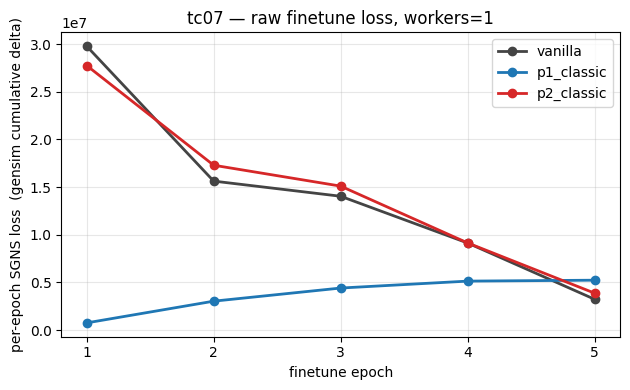

In [7]:
order = ["vanilla", f"p1_{SUFFIX}", f"p2_{SUFFIX}"]
colors = {order[0]: "#444444", order[1]: "#1f77b4", order[2]: "#d62728"}
epochs_x = list(range(1, EPOCHS + 1))

fig, ax = plt.subplots(figsize=(6.4, 4.0))
for name in order:
    ax.plot(epochs_x, results[name]["losses"], marker="o", ms=6, lw=2,
            color=colors[name], label=name)
ax.set_xlabel("finetune epoch")
ax.set_ylabel("per-epoch SGNS loss  (gensim cumulative delta)")
ax.set_title(f"{TC} — raw finetune loss, workers={WORKERS}")
ax.set_xticks(epochs_x)
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
fig.savefig(CACHE.parent / f"loss_raw_{SUFFIX}_w{WORKERS}.png", dpi=130)
plt.show()

## Loss normalized to per-pair (per training token)

gensim's `get_latest_training_loss()` is a **sum** over all skip-gram updates in
the epoch, so its magnitude scales with corpus size. Dividing by the number of
training tokens per epoch (`model.corpus_total_words`) gives a scale-free
*loss-per-pair* — each token spawns a near-constant number of (center, context)
pairs, so per-token ∝ per-pair.

**Caveat for this plot:** all three variants train on the *same* tc07 instance
corpus, so they share the same denominator. Within this notebook the
normalization only rescales the y-axis and does **not** change how entangled the
curves are. The per-pair scale matters when comparing *across* corpora (synthetic
vs DBpedia, or different walk budgets), where the raw summed loss is not
comparable.

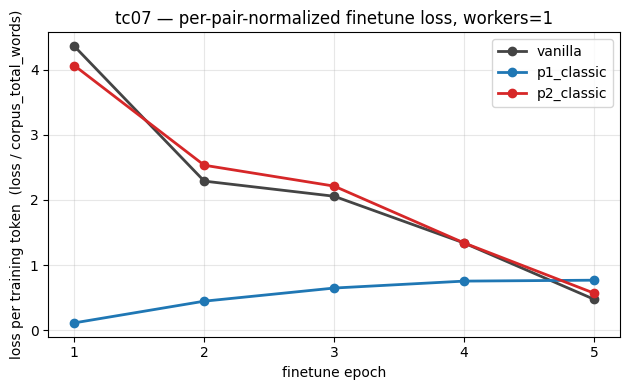

In [8]:
fig, ax = plt.subplots(figsize=(6.4, 4.0))
for name in order:
    n = results[name]["tokens_per_epoch"]
    per_pair = [l / n for l in results[name]["losses"]]
    ax.plot(epochs_x, per_pair, marker="o", ms=6, lw=2, color=colors[name], label=name)
ax.set_xlabel("finetune epoch")
ax.set_ylabel("loss per training token  (loss / corpus_total_words)")
ax.set_title(f"{TC} — per-pair-normalized finetune loss, workers={WORKERS}")
ax.set_xticks(epochs_x)
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
fig.savefig(CACHE.parent / f"loss_perpair_{SUFFIX}_w{WORKERS}.png", dpi=130)
plt.show()

In [9]:
# --- quantitative diagnosis ---
print(f"{'variant':<12} {'final_acc':>9}   per-epoch loss")
for name in order:
    r = results[name]
    print(f"{name:<12} {r['accs'][-1]:>9.3f}   [{' '.join(f'{l:9.1f}' for l in r['losses'])}]")

L = np.array([results[name]["losses"] for name in order])  # (3, EPOCHS)
spread = L.max(0) - L.min(0)
rel = spread / np.abs(L.mean(0))
print("\nper-epoch spread across variants (max-min):", [round(s, 1) for s in spread])
print("relative spread (spread / mean):           ", [round(x, 3) for x in rel])
print(f"\nshared denominator corpus_total_words = {results['vanilla']['tokens_per_epoch']:,}")

variant      final_acc   per-epoch loss
vanilla          0.590   [29791024.0 15634152.0 14044564.0 9138556.0 3235592.0]
p1_classic       0.555   [ 757838.8 3035770.7 4413842.5 5140872.0 5237084.0]
p2_classic       0.527   [27761392.0 17300684.0 15108072.0 9147060.0 3877184.0]

per-epoch spread across variants (max-min): [np.float64(29033185.2), np.float64(14264913.3), np.float64(10694229.5), np.float64(4006188.0), np.float64(2001492.0)]
relative spread (spread / mean):            [np.float64(1.494), np.float64(1.19), np.float64(0.956), np.float64(0.513), np.float64(0.486)]

shared denominator corpus_total_words = 6,827,621


## Is the loss being corrupted by gensim's float32 accumulator?

gensim accumulates `compute_loss` in a **single-precision (float32)** running total
that is **not reset** across a multi-epoch `train()` call (confirmed in the shipped
cython, `word2vec_inner.pyx`: `REAL_t *_running_training_loss_param`). float32
represents integers exactly only up to `2**24 = 16,777,216`. The cell below shows
the cumulative loss for each variant against that ceiling, then demonstrates the
rounding loss directly.

In [10]:
CEIL = 2 ** 24  # 16,777,216 — largest integer float32 represents exactly
print(f"float32 exact-integer ceiling 2**24 = {CEIL:,}\n")
print("cumulative running_training_loss per epoch  (* = past the ceiling):")
for name in order:
    cum = np.cumsum(results[name]["losses"])
    cells_ = [f"{c/1e6:6.1f}M{'*' if c > CEIL else ' '}" for c in cum]
    print(f"  {name:<12} " + "  ".join(cells_))

print("\ndirect demonstration — add 1.0 a million times to a float32 accumulator:")
for base in (0.0, 3e7, 7e7):
    a = np.float32(base)
    one = np.float32(1.0)
    for _ in range(1_000_000):
        a = np.float32(a + one)
    ulp = float(np.spacing(np.float32(base if base else 1.0)))
    print(f"  start {base/1e6:5.1f}M (ulp~{ulp:>4.1f}): added 1.0 x 1,000,000 "
          f"-> float32 captured {float(a) - base:>12,.0f}")
print("\ngensim's per-pair loss increments are O(0.1-2), so once the running total")
print("is in the 30-70M range the same rounding silently eats them.")

float32 exact-integer ceiling 2**24 = 16,777,216

cumulative running_training_loss per epoch  (* = past the ceiling):
  vanilla        29.8M*    45.4M*    59.5M*    68.6M*    71.8M*
  p1_classic      0.8M      3.8M      8.2M     13.3M     18.6M*
  p2_classic     27.8M*    45.1M*    60.2M*    69.3M*    73.2M*

direct demonstration — add 1.0 a million times to a float32 accumulator:


  start   0.0M (ulp~ 0.0): added 1.0 x 1,000,000 -> float32 captured    1,000,000


  start  30.0M (ulp~ 2.0): added 1.0 x 1,000,000 -> float32 captured            0


  start  70.0M (ulp~ 8.0): added 1.0 x 1,000,000 -> float32 captured            0

gensim's per-pair loss increments are O(0.1-2), so once the running total
is in the 30-70M range the same rounding silently eats them.


## Findings

**Setup.** vanilla / p1_classic / p2_classic on tc07, `workers=1`, seed=42 (fully
deterministic), finetune LR = 0.025 for all three. Per-epoch loss = delta of
gensim's cumulative `get_latest_training_loss()` — the *exact* bookkeeping the
benchmark (`run_synthetic_benchmark.py::_EpochTracker`) uses, with only the worker
count changed.

**1. `workers=1` removes the noise.** The curves are now smooth and monotonic
(vanilla & p2 decrease every epoch; p1 rises every epoch) instead of the jagged
16-worker benchmark curves. So the *jitter* in the benchmark plots is largely a
multi-thread (Hogwild) artifact: 16 threads race on the shared loss accumulator.

**2. ...but the entanglement remains.** vanilla and p2_classic are still nearly on
top of each other:

| epoch | vanilla | p2_classic | p1_classic |
|------:|--------:|-----------:|-----------:|
| 1 | 29.8M | 27.8M | 0.76M |
| 2 | 15.6M | 17.3M | 3.04M |
| 3 | 14.0M | 15.1M | 4.41M |
| 4 | 9.14M | 9.15M | 5.14M |
| 5 | 3.24M | 3.88M | 5.24M |

p1 is the only curve that separates — because its protograph init starts the
instance vectors at an already-low SGNS loss (0.76M) and the high finetune LR then
*erases* the init (loss rises). So `workers` is **not** the cause of the
entanglement.

**3. The real culprit: float32 saturation of the never-reset loss accumulator.**
The cumulative loss blows far past float32's `2**24 = 16.7M` exact-integer ceiling:
vanilla reaches **71.8M**, p2 **73.2M**, while p1 only reaches **18.6M** (near the
ceiling). In the saturated regime (ulp ≈ 4-8 at 30-70M) the O(1) per-pair
increments get rounded away, so (a) the late-epoch "decrease" is partly an artifact
of the accumulator dropping increments, and (b) different high-loss variants get
compressed toward the same measured values → **vanilla ≈ p2**. p1 stays under the
ceiling, so it is the one curve measured faithfully.

**4. Per-pair normalization is just a rescale here.** All three variants share the
tc07 corpus (6,827,621 tokens), so dividing by `corpus_total_words` is the same
constant for every curve — it changes the y-axis units, not the entanglement. That
axis matters for comparing *across* corpora (synthetic vs DBpedia), not within one.

**Why DBpedia looks clean by contrast.** `scripts/_invest_full_three.py` calls
`train(epochs=1)` in a loop, which **resets** the float32 accumulator every epoch,
and its variants are heavily under-trained on 1.16B tokens so their loss
*differences* dwarf the saturation. Here, a single un-reset 5-epoch call lets the
accumulator saturate and squashes the curves together.

**Fixes**
- Record loss the DBpedia way — one `train(epochs=1)` per epoch with a manual alpha
  schedule, reading a freshly-reset loss each epoch (each epoch's sum is smaller,
  though a 6.8M-token epoch still approaches the ceiling).
- For a fully reliable curve, compute the loss yourself in float64 over a fixed
  held-out batch of (center, context) pairs each epoch.
- Keep `workers=1` (or average several seeds) for any publication loss plot.